In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

years = [2019, 2020, 2021, 2022, 2023, 2024]

modes = {}
graphs = {}

base_modes = "../../data/03_modes"

# List all year_month folders
year_months = sorted([
    d for d in os.listdir(base_modes)
    if "_" in d and os.path.isdir(os.path.join(base_modes, d))
])

for ym in year_months:
    year, month = ym.split("_")
    for speed in ["fast", "medium", "slow"]:
        file_path = f"../../data/04_graphs/{ym}/{speed}_graph.gpickle"
        with open(file_path, "rb") as f:
            graphs[f"graph_{speed}_{ym}"] = pickle.load(f)
                
        modes[f"{speed}_{ym}"] = pd.read_parquet(f"../../data/03_modes/{ym}/{speed}_emd.parquet")

In [10]:
data = []

for name, G in graphs.items():
    _, speed, year, month = name.split("_")
    ym = str(year) + "_" + str(month)

    # Métricas básicas
    degrees = dict(G.degree(weight="weight"))
    wc = nx.clustering(G, weight="weight")

    assort = nx.degree_assortativity_coefficient(G)

    # --- Resistance distance completa ---
    R = dict(nx.resistance_distance(G, weight="weight"))
    nodes = list(G.nodes())

    # Métrica nodal correta
    nodal_resistance = {
        i: np.mean([R[i][j] for j in nodes if j != i])
        for i in nodes
    }

    for node in G.nodes():
        data.append({
            "node": node,
            "degree": degrees[node],
            "nodal_resistance": nodal_resistance[node],
            "speed": speed.capitalize(),
            "year_month": ym,
            "weighted_clustering": wc[node],
            "assortativity": assort
        })

df = pd.DataFrame(data)

In [13]:
df["year_month_dt"] = pd.to_datetime(df["year_month"], format="%Y_%m")

## Reading data

In [44]:
df = pd.read_parquet("../../data/05_metrics/graph_metrics_df.parquet")

In [45]:
df_sector = pd.read_parquet("../../data/01_raw/screener_result.parquet")[["Ticker", "Sector", "Market Cap"]]
df = df.merge(df_sector, how="left", left_on="node", right_on="Ticker").drop(columns="Ticker")

## Análise 1 - Weighted degree

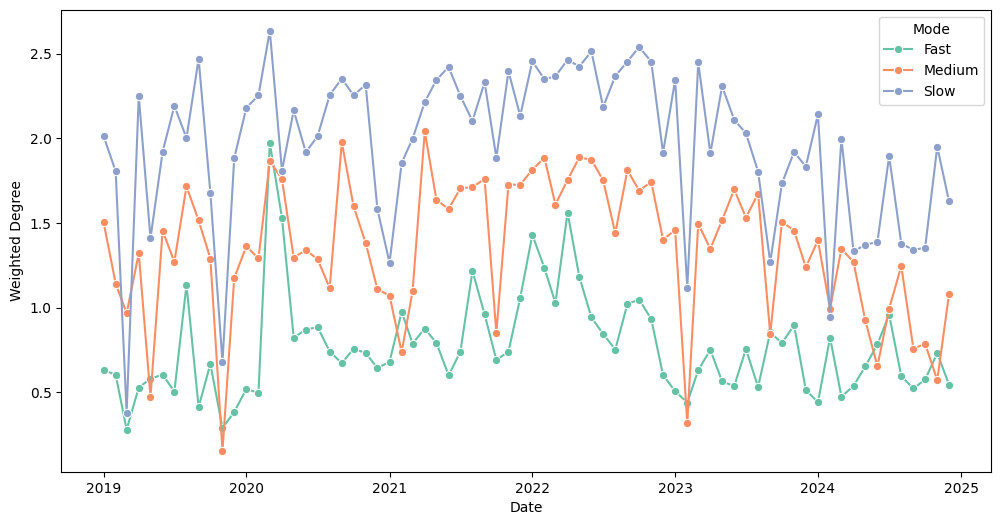

In [56]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"degree": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="degree",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Weighted Degree")
plt.show()

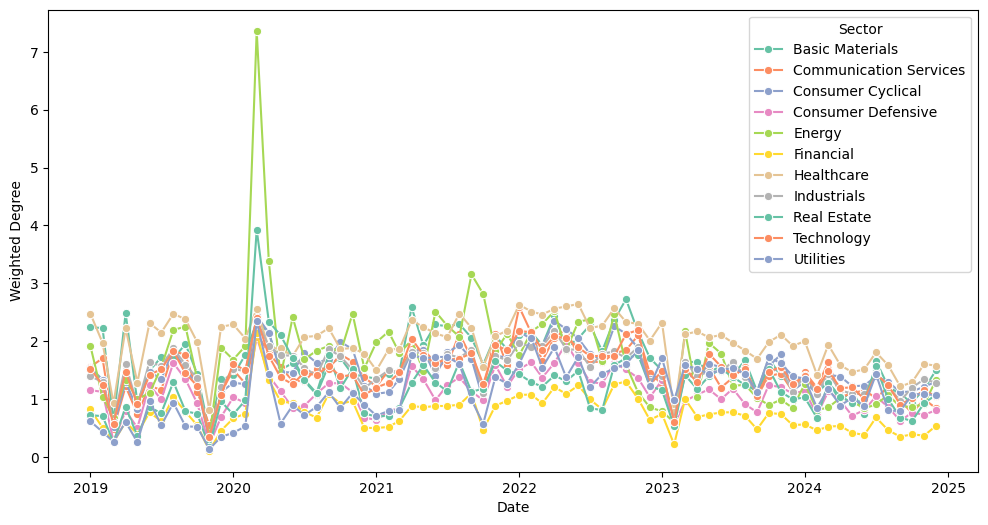

In [86]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "Sector"], as_index=False)
      .agg({"degree": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="degree",
    hue="Sector",
    palette="Set2",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Weighted Degree")
plt.show()

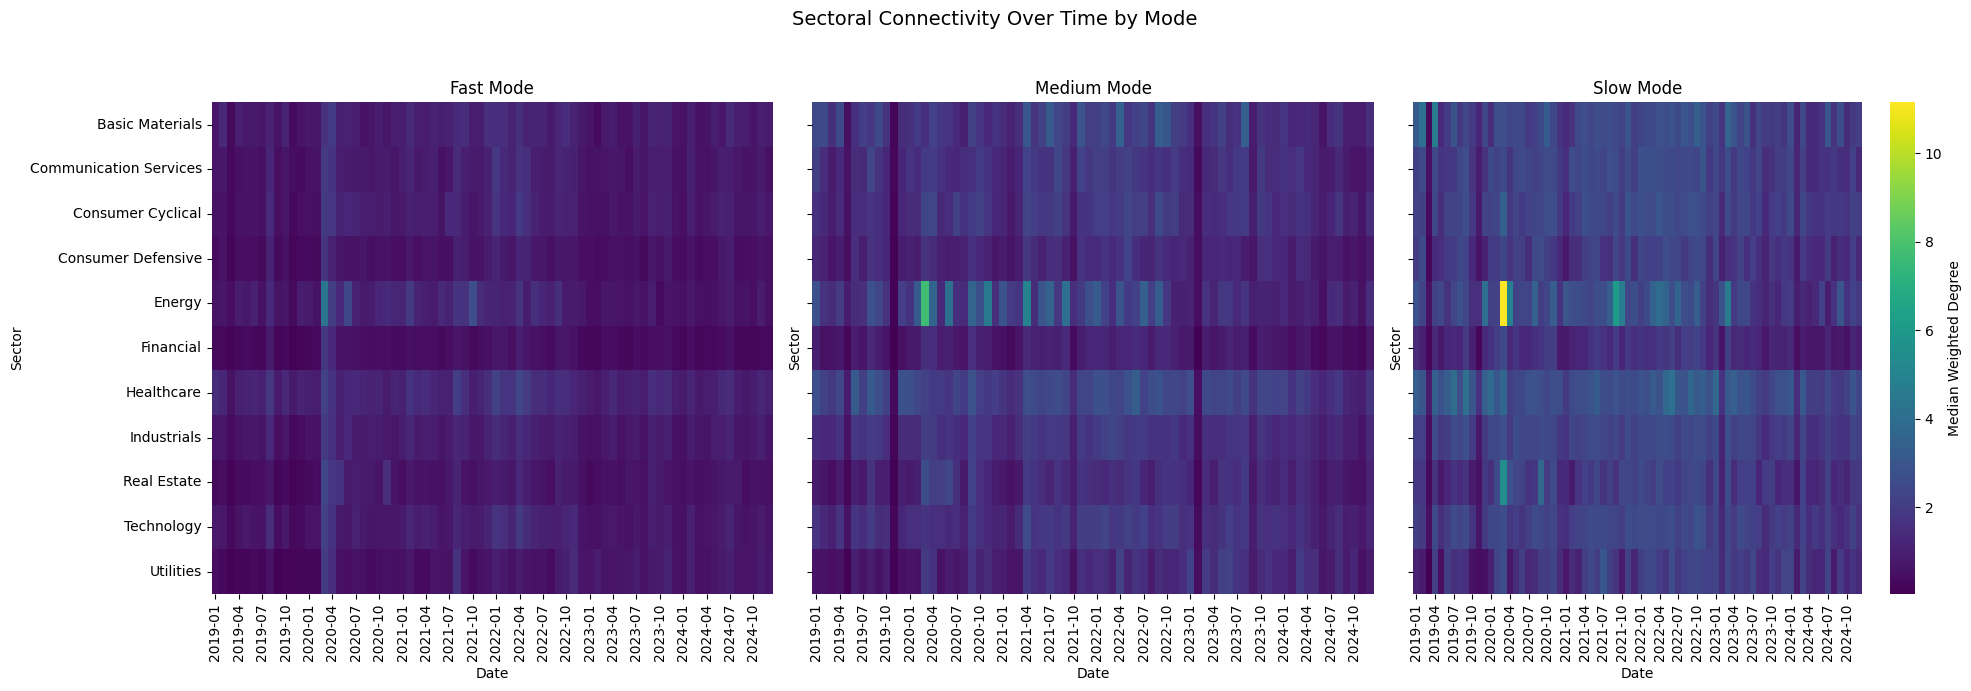

In [93]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"degree": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="degree"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Degree"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Connectivity Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_25360\889792095.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin"], as_index=False)


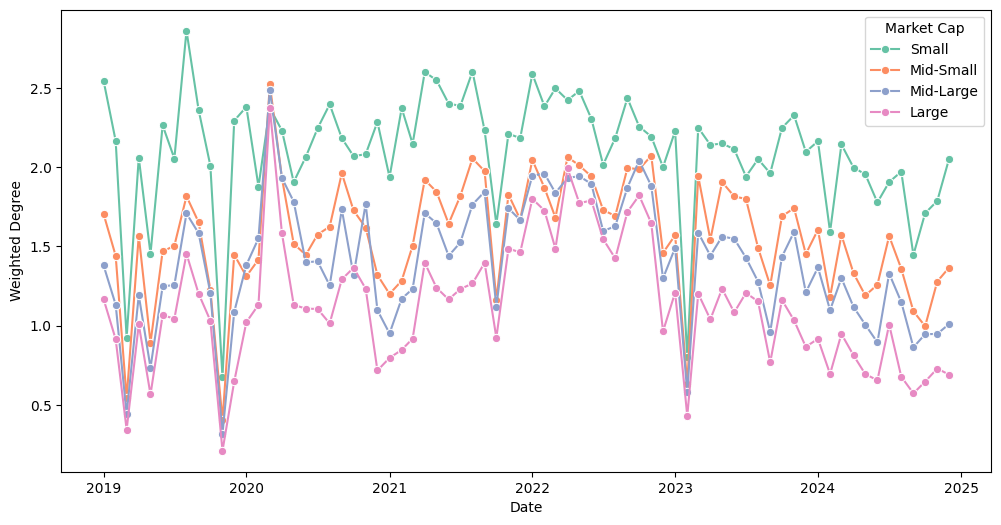

In [57]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "mcap_bin"], as_index=False)
      .agg({"degree": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="degree",
    hue="mcap_bin",
    palette="Set2",
    marker="o"
)

plt.legend(title="Market Cap")
plt.xlabel("Date")
plt.ylabel("Weighted Degree")
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_25360\3861215459.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


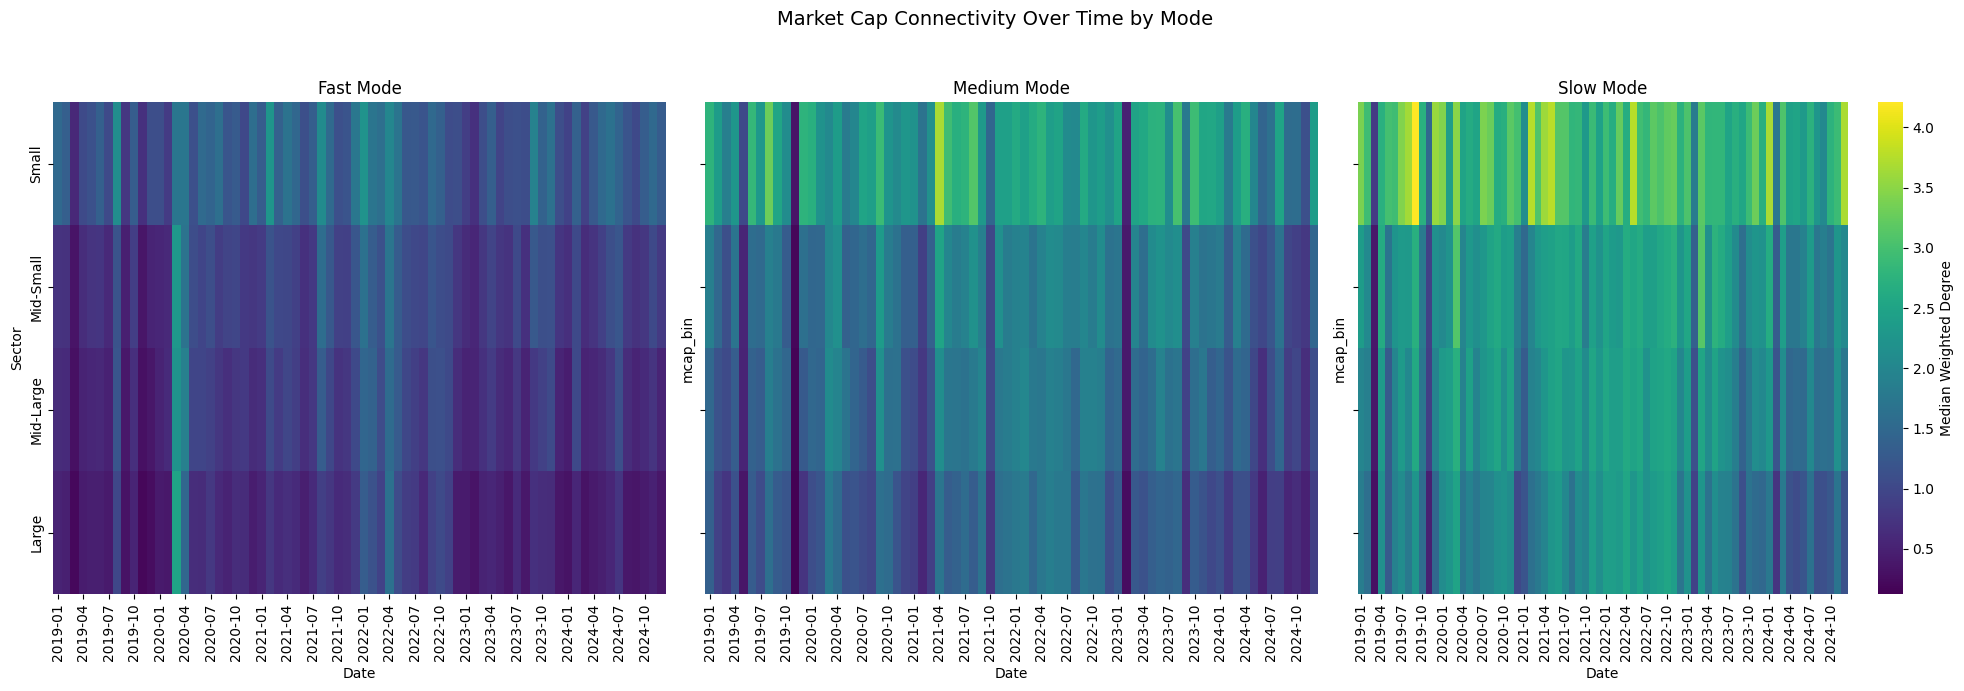

In [100]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"degree": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="degree"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Degree"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Connectivity Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Análise 2: Resistance distance

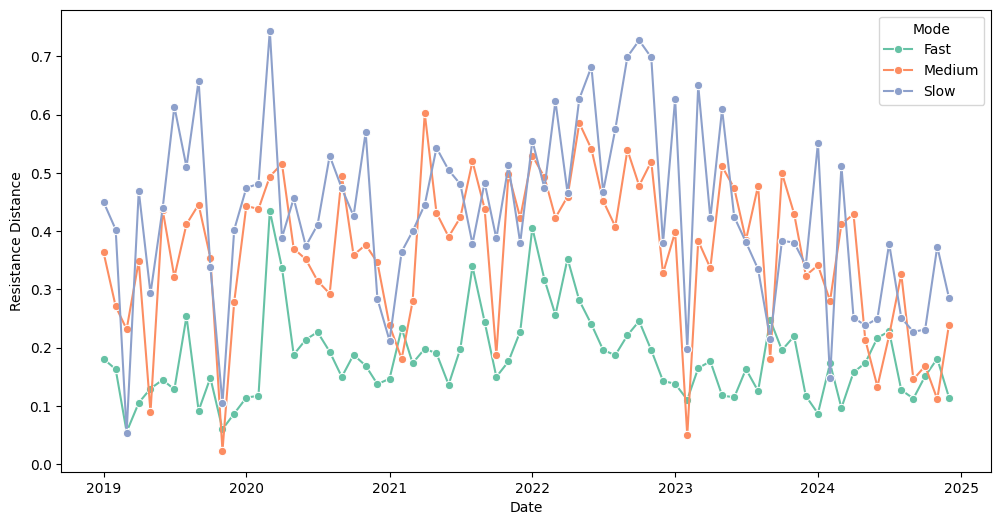

In [61]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="nodal_resistance",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Resistance Distance")
plt.show()

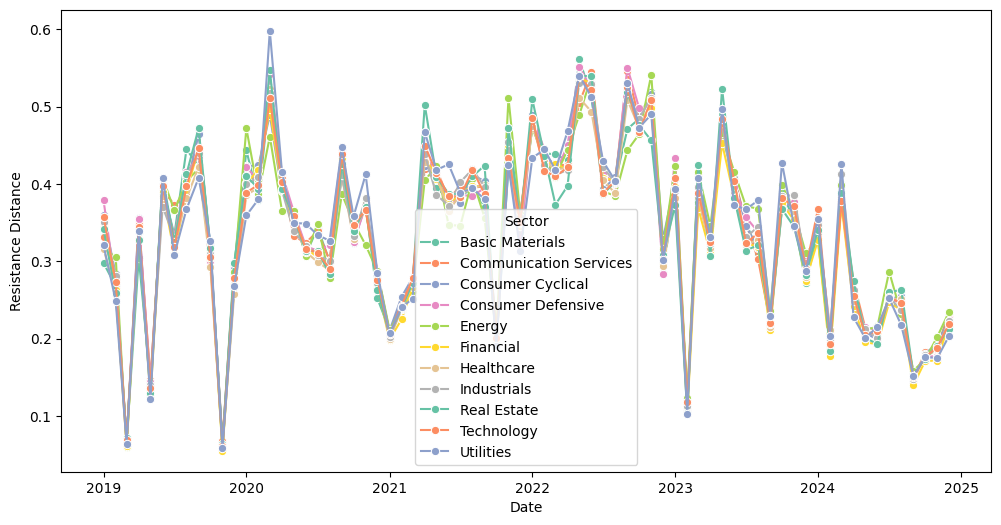

In [64]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "Sector"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="nodal_resistance",
    hue="Sector",
    palette="Set2",
    marker="o"
)

plt.legend(title="Sector")
plt.xlabel("Date")
plt.ylabel("Resistance Distance")
plt.show()

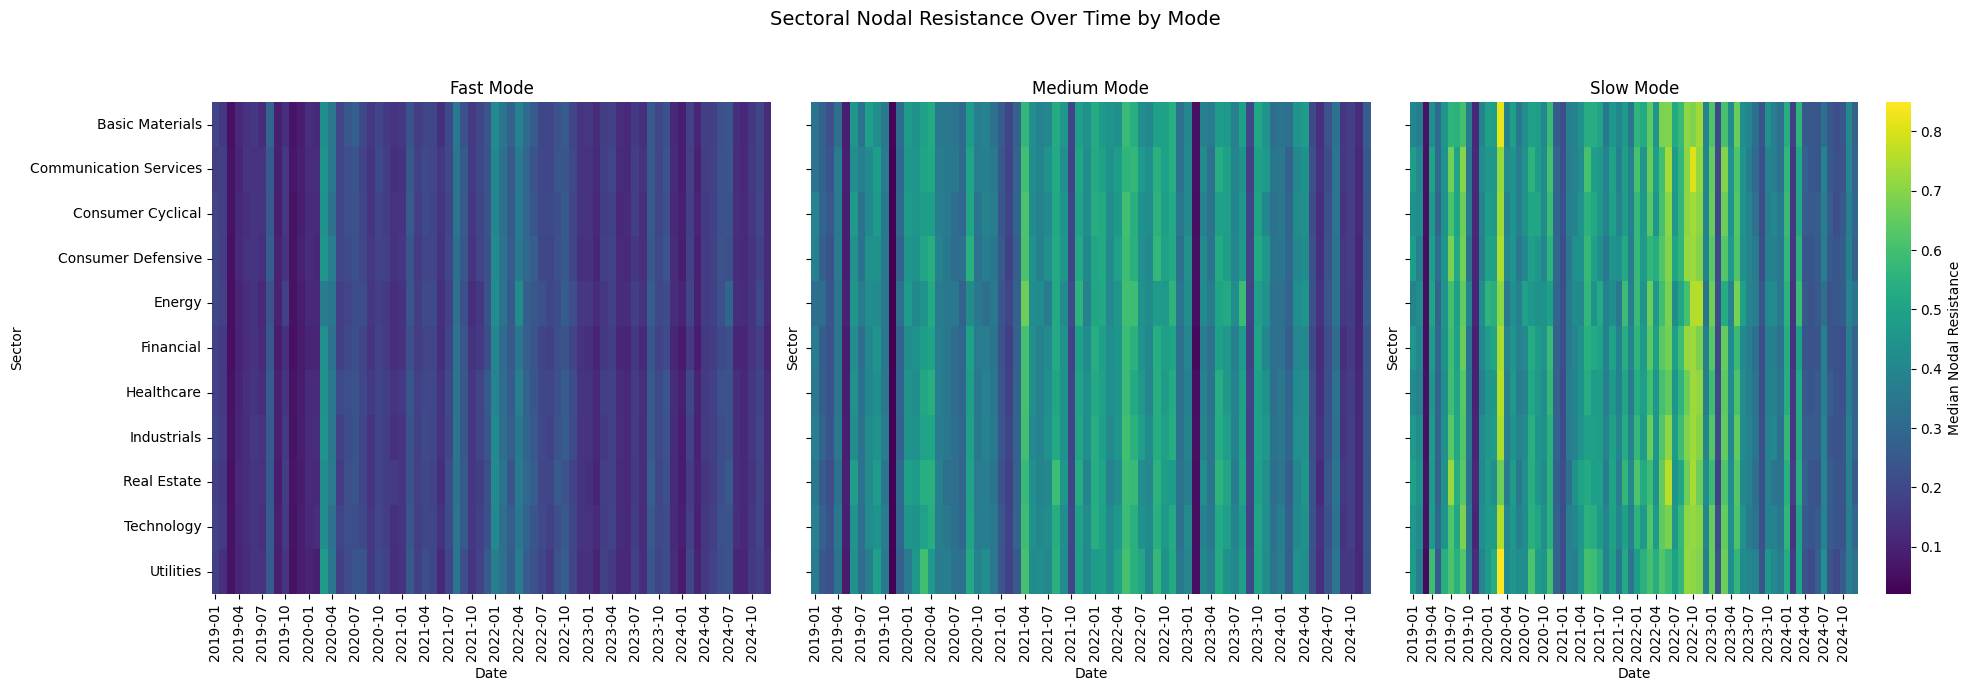

In [95]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="nodal_resistance"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Nodal Resistance"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Nodal Resistance Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_25360\152774215.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin"], as_index=False)


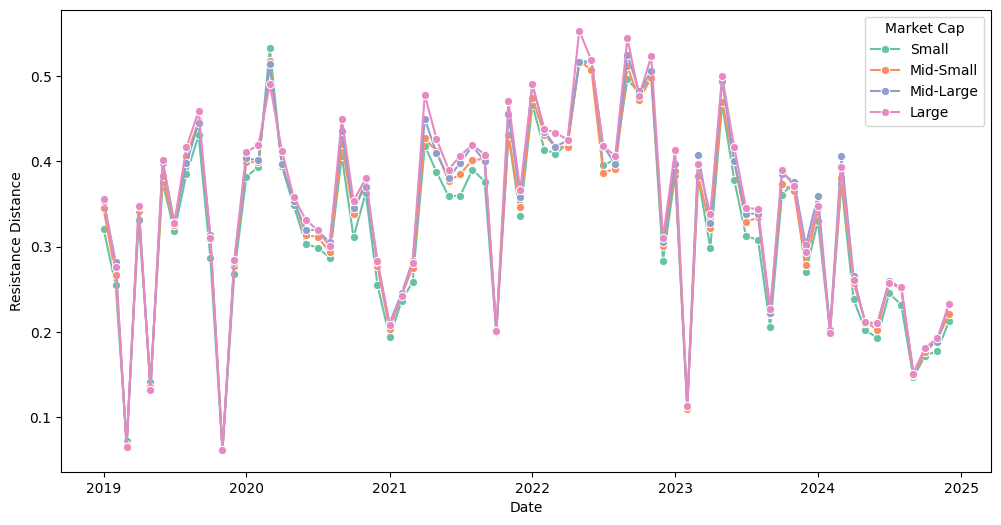

In [65]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "mcap_bin"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="nodal_resistance",
    hue="mcap_bin",
    palette="Set2",
    marker="o"
)

plt.legend(title="Market Cap")
plt.xlabel("Date")
plt.ylabel("Resistance Distance")
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_25360\233264478.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


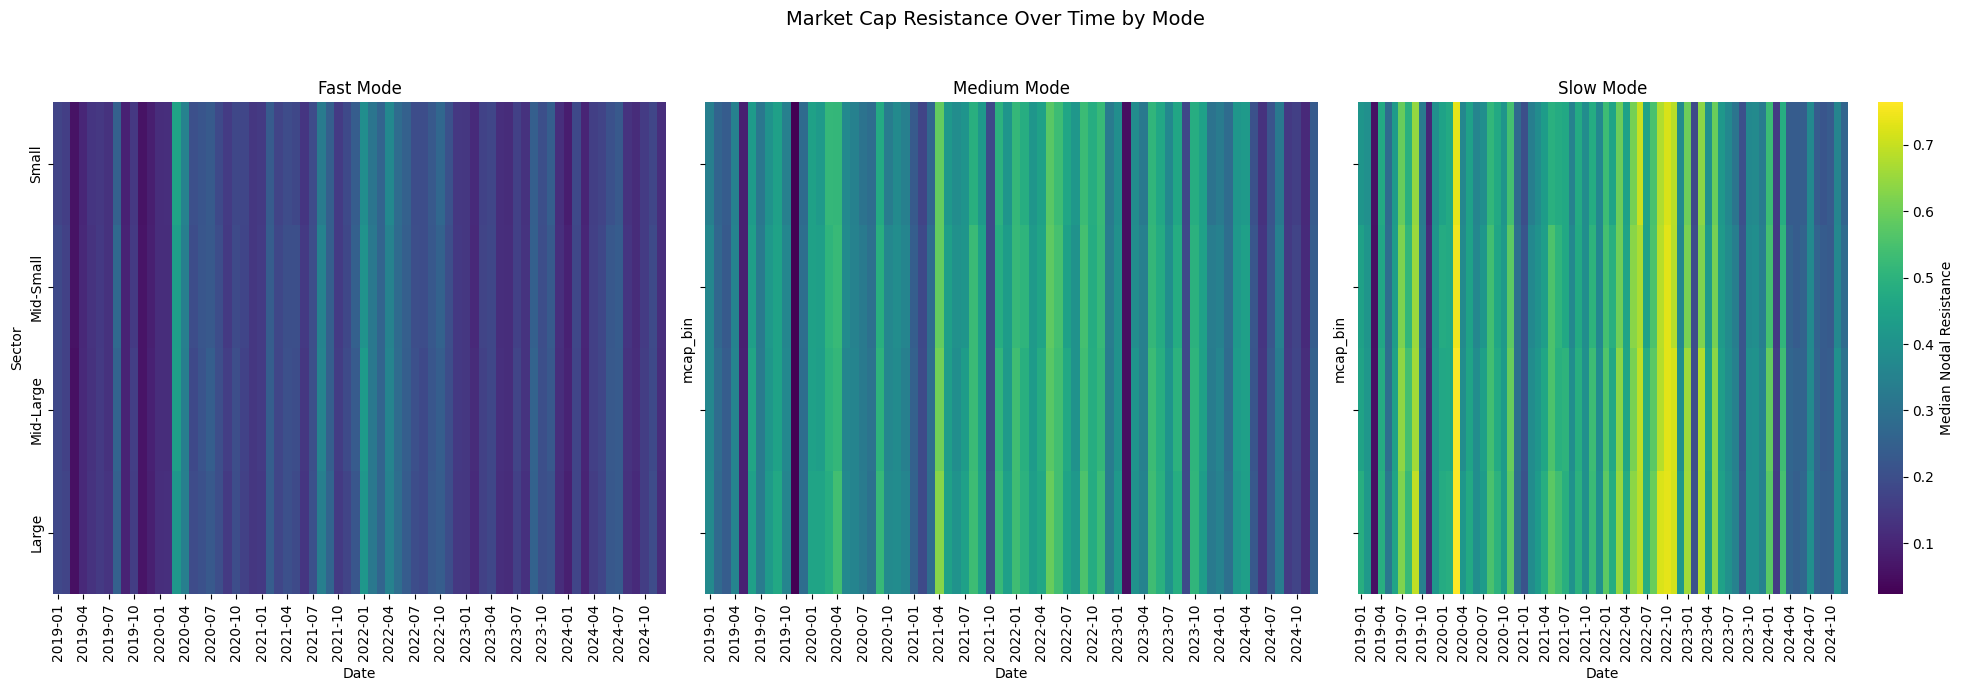

In [99]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="nodal_resistance"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Nodal Resistance"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Resistance Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Análise 3: Clustering

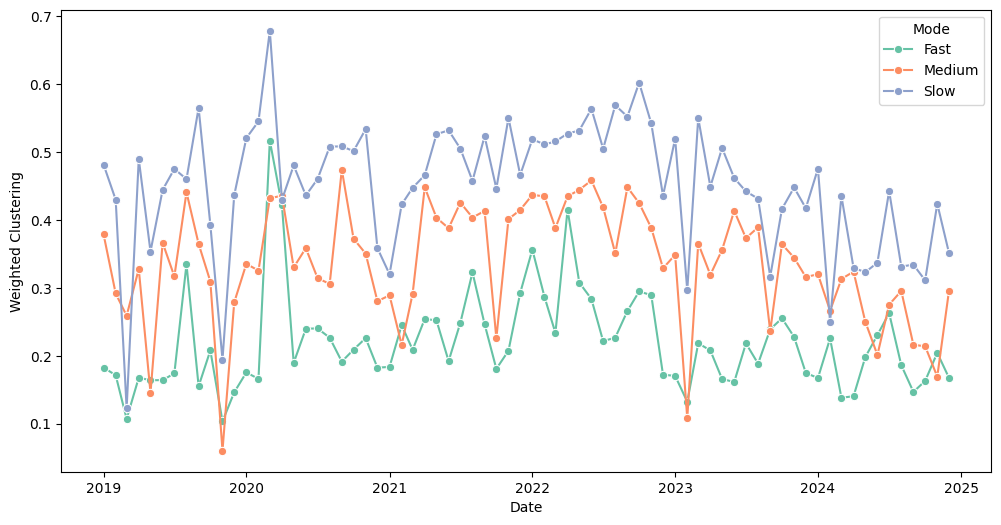

In [67]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="weighted_clustering",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Weighted Clustering")
plt.show()

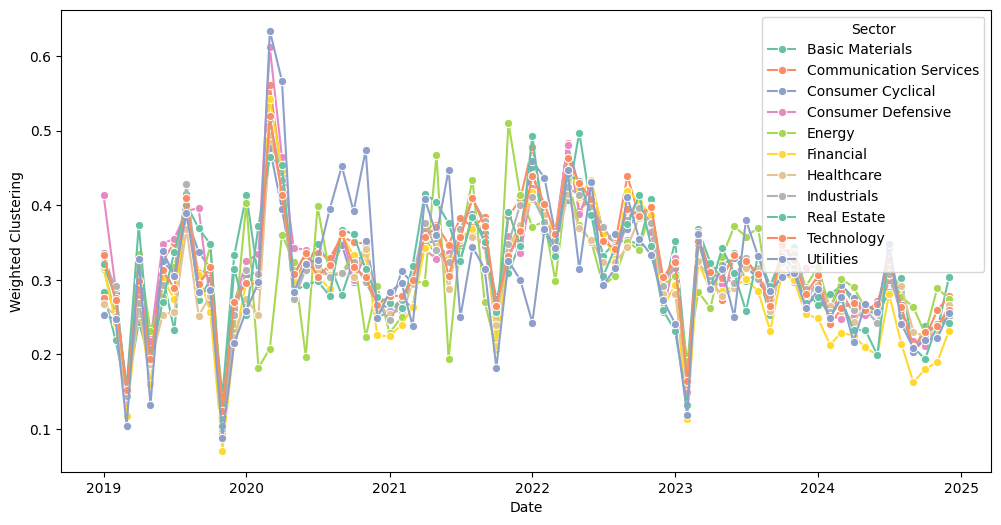

In [68]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "Sector"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="weighted_clustering",
    hue="Sector",
    palette="Set2",
    marker="o"
)

plt.legend(title="Sector")
plt.xlabel("Date")
plt.ylabel("Weighted Clustering")
plt.show()

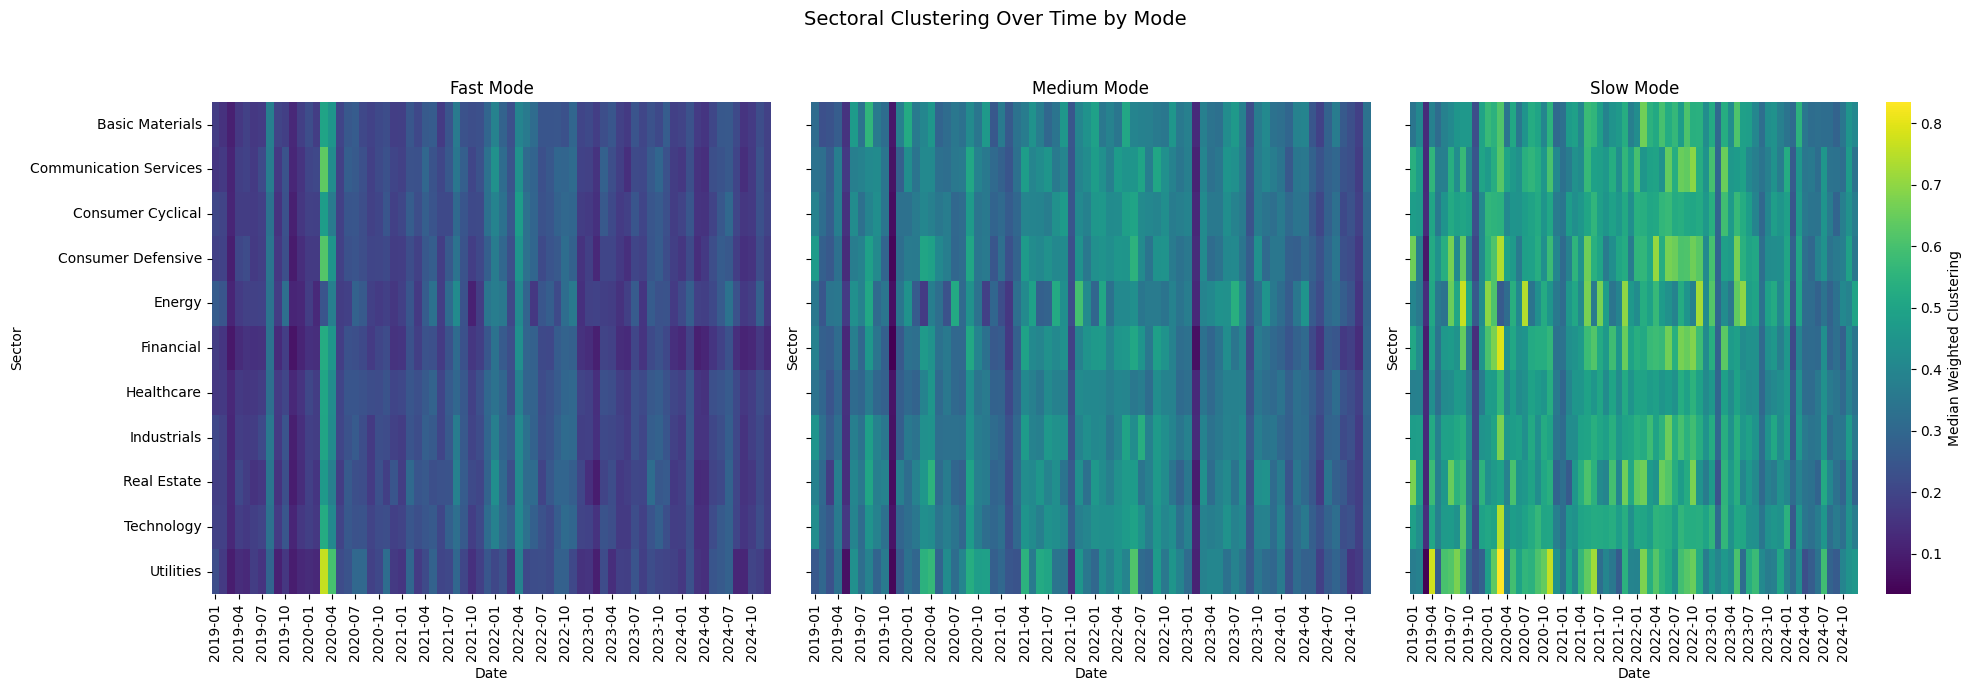

In [96]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="weighted_clustering"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Clustering"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Clustering Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_25360\2890251909.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


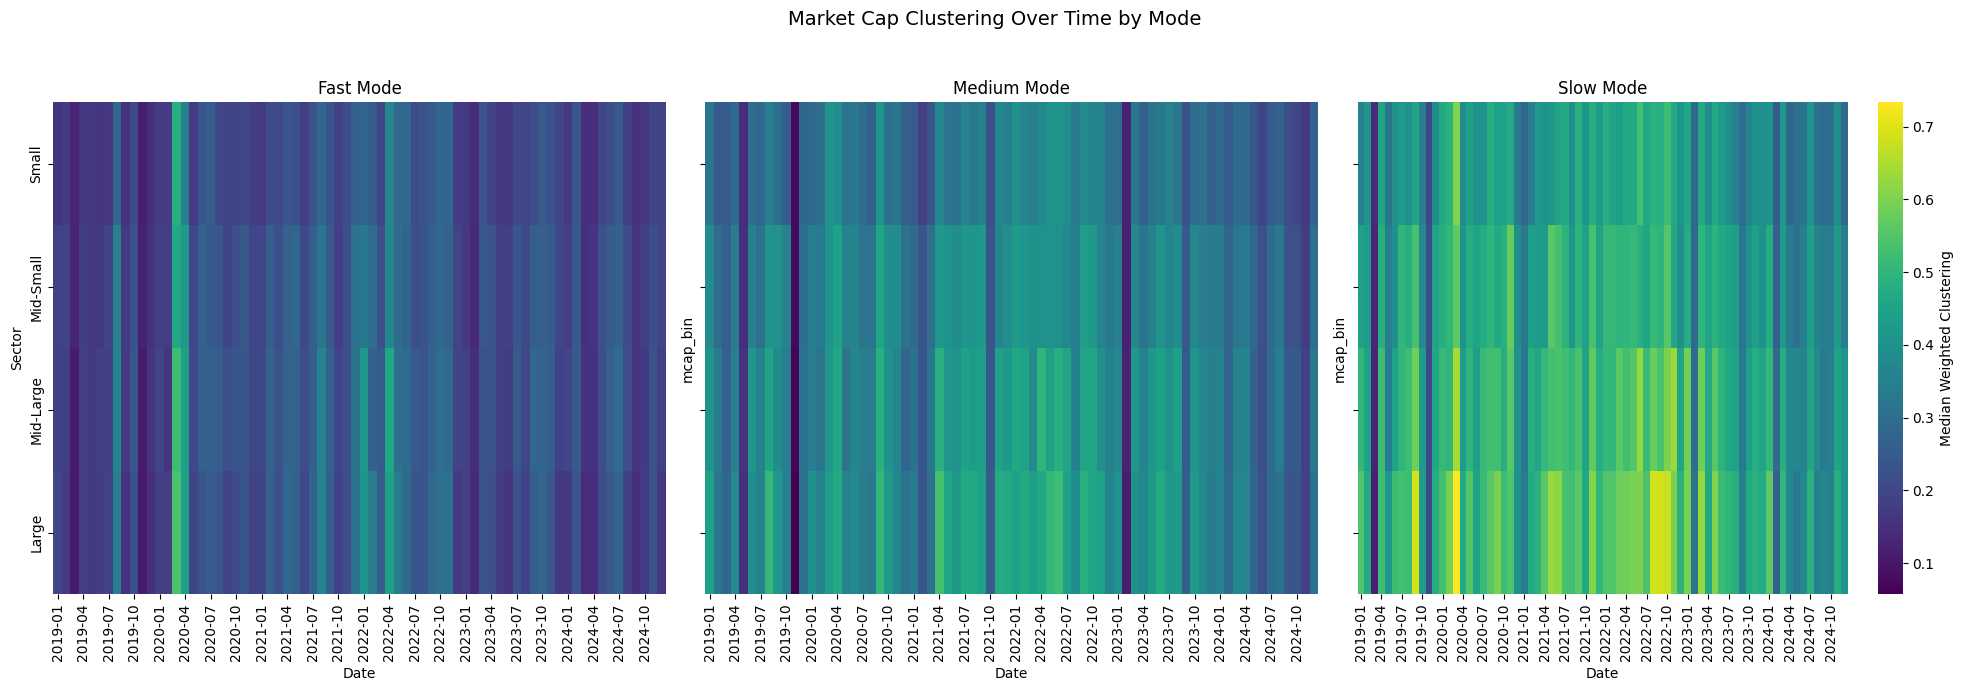

In [98]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="weighted_clustering"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Clustering"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Clustering Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_25360\3115343470.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin"], as_index=False)


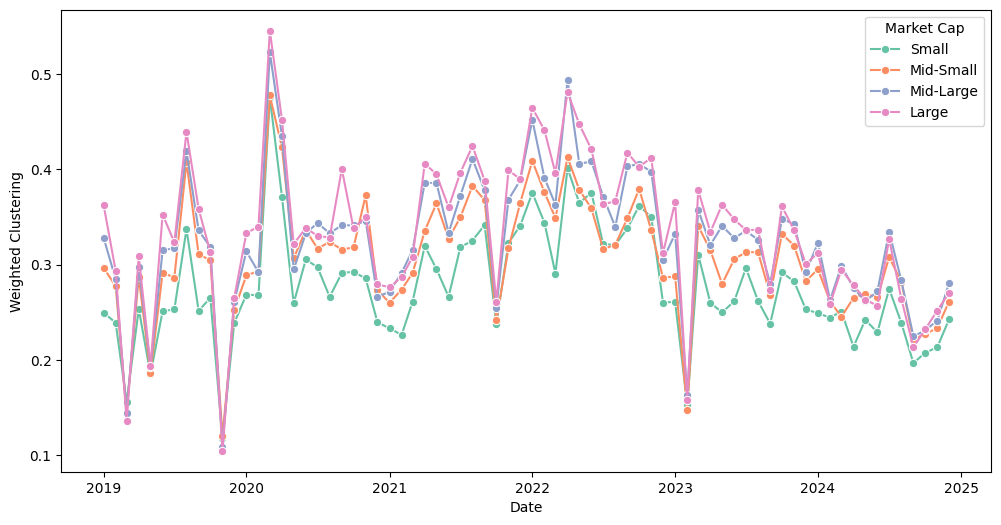

In [97]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "mcap_bin"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="weighted_clustering",
    hue="mcap_bin",
    palette="Set2",
    marker="o"
)

plt.legend(title="Market Cap")
plt.xlabel("Date")
plt.ylabel("Weighted Clustering")
plt.show()

## Análise 4 - Assortatividade

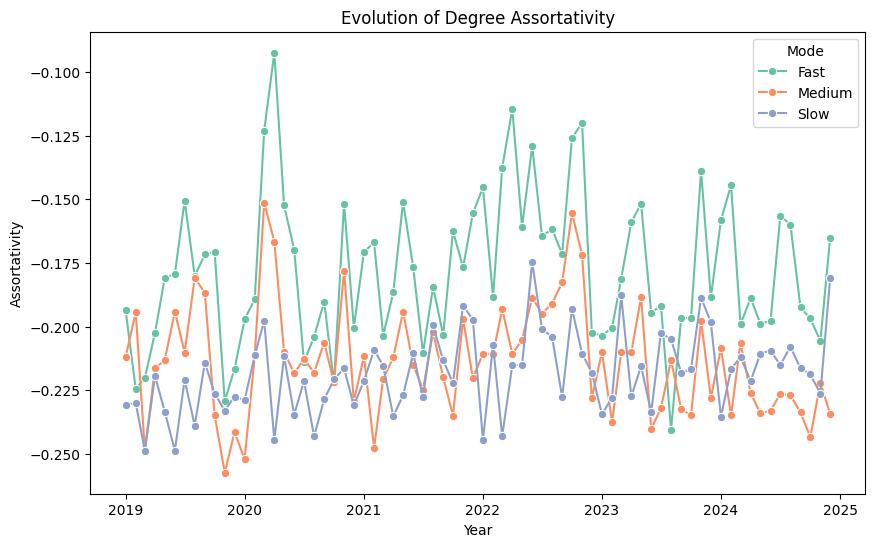

In [101]:
df_assort = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({
          "assortativity": "first"
      })
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_assort,
    x="year_month_dt",
    y="assortativity",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Assortativity")
plt.title("Evolution of Degree Assortativity")
plt.legend(title="Mode")
plt.show()